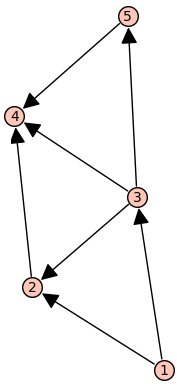

In [1]:
g = DiGraph(weighted = True)
g.add_edges([(1, 2, 8), (1,3,2), (2,4,1), (3,2,5), (3,4, 11), (3,5,1), (5, 4, 9)])
g.show()

In [2]:
M = g.weighted_adjacency_matrix()
print(M)

[ 0  8  2  0  0]
[ 0  0  0  1  0]
[ 0  5  0 11  1]
[ 0  0  0  0  0]
[ 0  0  0  9  0]


In [ ]:
def bellman(g):
    # --- PRÉPARATION (Début de votre code) ---
    N = g.topological_sort() # Exemple : N = [1, 3, 2, 5, 4]
    n = g.order()            # Nombre total de sommets (ici 5)
    
    # --- INITIALISATION ---
    D = n * [Infinity]       # Liste des distances : [Inf, Inf, Inf, Inf, Inf]
    P = n * [0]              # Liste des prédécesseurs : [0, 0, 0, 0, 0]
    
    D[0] = 0                 # La case 0 correspond au sommet de départ (N[0])
    P[0] = N[0]              # On met le départ comme son propre prédécesseur
    
    # --- LA BOUCLE PRINCIPALE ---
    for i in range(1, n):
        sommet_i = N[i]      # On regarde le sommet actuel
        
        # On récupère les voisins entrants avec notre fonction
        pred = predecesseurs(g, sommet_i)
        
        # VOTRE LIGNE EXACTE : D[i] = min( [d(j) + f(j, i) for j in pred] )
        # - d(j) s'écrit D[N.index(j)] (on va chercher la distance de j dans la liste D)
        # - f(j, i) s'écrit g.edge_label(j, sommet_i) (c'est le poids de la flèche)
        D[i] = min([D[N.index(j)] + g.edge_label(j, sommet_i) for j in pred])
        
        # --- TROUVER LE PRÉDÉCESSEUR P(i) ---
        # Le min() a trouvé la plus petite distance, mais on doit savoir quel "j" a gagné.
        # On refait le calcul pour trouver le coupable :
        for j in pred:
            if D[N.index(j)] + g.edge_label(j, sommet_i) == D[i]:
                P[i] = j
                
    # --- AFFICHAGE POUR LE TP ---
    # Actuellement, D et P sont rangés dans l'ordre topologique (1, 3, 2, 5, 4).
    # Mais le TP demande de les afficher dans l'ordre des numéros (1, 2, 3, 4, 5).
    # On va juste recréer deux petites listes propres pour le résultat final.
    D_final = []
    P_final = []
    
    for sommet in sorted(g.vertices()):
        # On regarde à quelle case était rangé ce sommet
        index_du_sommet = N.index(sommet)
        
        # On ajoute la bonne distance et le bon prédécesseur
        D_final.append(D[index_du_sommet])
        P_final.append(P[index_du_sommet])
        
    return D_final, P_final

In [3]:
g.edges()

[(1, 2, 8), (1, 3, 2), (2, 4, 1), (3, 2, 5), (3, 4, 11), (3, 5, 1), (5, 4, 9)]

# EXERCICE 1

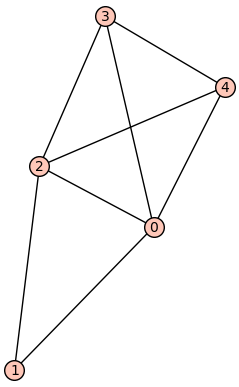

[0 2 4 3 6]
[2 0 7 0 0]
[4 7 0 2 8]
[3 0 2 0 1]
[6 0 8 1 0]


In [10]:

g2 = Graph(weighted = True)


g2.add_edges([
    (0, 1, 2), 
    (0, 2, 4), 
    (0, 3, 3),
    (0, 4, 6),
    (1, 2, 7), 
    (2, 3, 2),
    (2, 4, 8),
    (3, 4, 1)
    
])


g2.show()


M2 = g2.weighted_adjacency_matrix()
print(M2)

In [13]:
g = DiGraph(weighted = True)
g.add_edges([(1, 2, 8), (1,3,2), (2,4,1), (3,2,5), (3,4, 11), (3,5,1), (5, 4, 9)])
N = g.topological_sort()
print(N)

[1, 3, 2, 5, 4]


In [14]:
print(Infinity > 9999)
print(Infinity + 82 == Infinity)
print(Infinity + 1 > Infinity)
print(Infinity*(-72) == -Infinity)

True
True
False
True


In [17]:
def bellman(g):
    N = g.topological_sort()
    n = g.order()
    D = n * [Infinity]
    D[0] = 0
    for i in range(1, n):
        pred =  []
        D[i] = min( [d(j) + f(j, i) for j in pred])
    return D




 

# EXERCICE : 2

In [1]:
def bellman(g):
    N = g.topological_sort()
    n = len(N)
    arcs = g.edges()

    # Initialisation
    D = []
    P = []
    for i in range(n):
        D.append(Infinity)
        P.append(N[0])
    D[0] = 0

    # Pour chaque sommet dans l'ordre topologique
    for i in range(1, n):
        x = N[i]
        # Chercher les prédécesseurs de x dans la liste des arcs
        for arc in arcs:
            if arc[1] == x:           
                j = arc[0]            
                poids = arc[2]        
                # Trouver la position de j dans N
                pos_j = 0
                for k in range(n):
                    if N[k] == j:
                        pos_j = k
                # Mettre à jour si le chemin est plus court
                if D[pos_j] + poids < D[i]:
                    D[i] = D[pos_j] + poids
                    P[i] = j
    return D, P

D, P = bellman(g)
print("Ordre topologique :", N)
print("Distances :", D)
print("Prédécesseurs :", P)

NameError: name 'g' is not defined